# De EDUKA a PDF: automatización de certificados académicos oficiales asistida por IA

**Proyecto Final — IA: Entretejiendo Imaginación y Algoritmos**


## Resumen

El liceo en donde me desempeño utiliza un sistema de gestión académica legado (EDUKA, desarrollado en Visual Basic 6 sobre una base Access de los años '90) que solo permite generar los certificados oficiales que exige ANEP (Formularios 69, 52, 05 y 69A/B) de a uno, de forma manual, buscando cada alumno en pantalla. Con más de 4.000 alumnos activos e históricos, este proceso es impracticable a escala y consume horas de trabajo administrativo por semana. Este proyecto extrae los datos académicos crudos directamente de la base del sistema, reconstruye la lógica de negocio (qué constituye una nota final vs. una nota parcial, cómo se determina si un alumno completó el Bachillerato, etc.) y usa modelos de lenguaje —combinando prompting de texto y de imagen— tanto para asistir en la interpretación/documentación de esa lógica como para producir automáticamente los ~4.000 documentos PDF finales, junto con material de apoyo (instructivo ilustrado) para el personal administrativo que los va a utilizar.

**Nota sobre privacidad**: todos los datos, ejemplos y capturas de este repositorio son **ficticios**. El proyecto original trabaja sobre datos reales de alumnos, pero para esta entrega pública se construyó un dataset sintético que preserva la misma estructura y complejidad (ver sección de Metodología).


## Introducción

### Nombre del proyecto
**De EDUKA a PDF: automatización de certificados académicos oficiales asistida por IA**

### Presentación del problema

El liceo en donde me desempeño gestiona los datos académicos de sus alumnos (más de 4.000 entre historial activo e histórico) en EDUKA, un sistema desarrollado en Visual Basic 6 sobre una base de datos Access de fines de los años '90. Este sistema permite emitir los documentos oficiales que exige la Administración Nacional de Educación Pública (ANEP) — constancias de escolaridad, certificados de estudios, certificados de egreso de Bachillerato — pero únicamente **de a un alumno por vez**, mediante una interfaz manual que requiere buscar cada ficha, revisarla y generar el documento individualmente.

Esta limitación convierte tareas simples en cuellos de botella severos: generar la documentación de un curso completo, o de todos los egresados de un año, puede demandar horas de trabajo administrativo repetitivo. A esto se suma un riesgo silencioso: al ser un proceso manual y repetitivo, es propenso a errores humanos difíciles de detectar (un dato mal tipeado, un criterio aplicado de forma inconsistente entre un alumno y otro) que pueden terminar en documentos oficiales incorrectos entregados a personas reales. Es una problemática relevante porque combina dos costos concretos: tiempo administrativo escaso y el riesgo de emitir documentación oficial errónea — algo con consecuencias legales y prácticas para quien la recibe (trámites de revalidación, becas, continuidad de estudios en el exterior).

### Desarrollo de la propuesta de solución

La solución combina dos componentes bien diferenciados. El primero es una **capa de extracción e ingeniería de datos** (no-IA): un módulo que lee directamente las tablas crudas de la base Access, reconstruye la lógica académica del sistema (qué distingue una nota final de una parcial, cómo se determina si una materia quedó aprobada, cómo se identifica si un alumno completó el Bachillerato) y genera los documentos PDF finales con el formato oficial exacto que exige ANEP.

El segundo componente, donde se aplican los modelos de IA vistos en el curso, cumple dos roles concretos dentro del proyecto:

- **Modelo texto-texto (Claude, vía API de Anthropic)**: se usa en tres etapas distintas, cada una con una técnica de *fast prompting* diferente:
  1. **Few-shot prompting** para clasificar y estandarizar textos de "actuación del estudiante" (ej. convertir códigos crudos de la base como `"A"`, `"R"`, `"L"` en las categorías oficiales `CAT.A`, `REG`, `LA`) a partir de un puñado de ejemplos etiquetados.
  2. **Chain-of-thought prompting** para que el modelo razone paso a paso, a partir de las notas crudas de un alumno, cuál es su situación académica final en una materia (aprobada, pendiente, en curso) — replicando y validando cruzada la lógica que también implementé en código determinístico.
  3. **Prompting con formato de salida restringido** para redactar automáticamente el texto de "Observaciones" de cada certificado en el registro burocrático/formal que exige ANEP, a partir de datos estructurados (fechas, resoluciones, expedientes).
- **Modelo texto-imagen** (herramienta gratuita, Nightcafe u otra): se usa para generar dos piezas visuales de apoyo al proyecto — un infográfico técnico que ilustra el pipeline completo (EDUKA → extracción → IA → PDF → entrega), y una versión ilustrada del instructivo operativo para el personal administrativo que va a usar el sistema en el día a día.

### Justificación de la viabilidad del proyecto

El proyecto es técnicamente viable dentro del tiempo y los recursos disponibles por varios motivos concretos. Primero, la extracción de datos no depende de ningún acceso privilegiado ni de modificar el sistema legado: la base es un archivo Access/Jet estándar, legible con herramientas ampliamente disponibles (`mdbtools`, o el driver ODBC de Microsoft), sin necesidad de licencias adicionales ni de intervenir el sistema en producción. Segundo, el volumen de datos es perfectamente manejable en un entorno de cómputo modesto: procesar la totalidad de los ~4.000 alumnos y generar todos los documentos toma menos de un minuto, lo que permite iterar y validar rápidamente durante el desarrollo. Tercero, los componentes de IA propuestos son acotados y de bajo costo: los prompts de texto operan sobre fragmentos de datos ya estructurados (no sobre la base completa), y los de imagen se limitan a un puñado de generaciones puntuales para material de apoyo, por lo que el consumo de créditos de API es mínimo.

El mayor desafío del proyecto no fue de recursos sino de **dominio del problema**: la lógica de negocio del sistema legado no está documentada en ningún lado y tuvo que reconstruirse por prueba y error, comparando la salida generada contra documentos reales ya emitidos por el sistema. Ese proceso de validación iterativa (y los errores reales que encontró y corrigió, incluyendo dos bugs que afectaban documentos oficiales ya emitidos) es en sí mismo evidencia de que el enfoque es viable y sostenible: el sistema no solo genera documentos, sino que permite detectar inconsistencias que el proceso manual anterior nunca hubiera revelado.


## Objetivos

**Objetivo general**

Automatizar la generación de los documentos académicos oficiales (Formularios 69, 52, 05 y 69A/B) exigidos por ANEP, reemplazando un proceso manual de a un alumno por vez, mediante extracción directa de datos y el uso de modelos de IA para asistir en tareas de clasificación, razonamiento y redacción sobre esos datos.

**Objetivos específicos**

1. Reconstruir y documentar la lógica de negocio del sistema legado (criterios de aprobación, período de régimen vs. examen, elegibilidad por tipo de documento) a partir de los datos crudos, sin acceso a documentación original.
2. Aplicar *few-shot prompting* para automatizar la clasificación/estandarización de categorías de calificación a partir de ejemplos.
3. Aplicar *chain-of-thought prompting* para que el modelo determine la situación académica final de un alumno en una materia, y validar ese resultado contra la lógica determinística ya implementada.
4. Aplicar *prompting con formato de salida restringido* para generar automáticamente texto de observaciones en el registro formal requerido.
5. Generar material visual de apoyo (infográfico técnico e instructivo ilustrado) mediante un modelo texto-imagen.
6. Validar la solución completa contra una muestra de casos reales conocidos, midiendo tanto exactitud de los datos como la reducción de tiempo respecto al proceso manual.


## Metodología

El proyecto se llevó a cabo en las siguientes etapas:

**1. Exploración y reconstrucción del modelo de datos.** Se analizaron las tablas crudas del sistema legado (Alumnos, Notas, Juicios, Períodos, Materias, entre otras) sin documentación disponible, comparando iterativamente la salida generada contra documentos reales ya emitidos por el sistema hasta reconstruir con precisión los criterios de negocio (qué período constituye una nota final, cómo se determina la aprobación de una materia, qué requisitos determinan la elegibilidad de cada tipo de documento).

**2. Construcción de un dataset ficticio.** Por motivos de privacidad, se generó un conjunto de datos sintético (alumnos, calificaciones y trayectorias académicas inventadas) que preserva la misma estructura y complejidad que los datos reales — incluyendo casos límite relevantes (alumnos con materias pendientes, alumnos que completaron el Bachillerato, alumnos con historial parcial) — para que el proyecto sea reproducible públicamente sin exponer información real.

**3. Diseño e implementación de prompts (texto-texto).** Se diseñaron tres prompts, cada uno aplicando una técnica de *fast prompting* distinta (few-shot, chain-of-thought, formato de salida restringido), ejecutados contra la API de Anthropic (Claude) sobre fragmentos del dataset ficticio.

**4. Validación cruzada.** Cada resultado generado por IA (clasificación, razonamiento, texto redactado) se comparó contra la lógica determinística ya implementada en código, para medir su exactitud y detectar discrepancias.

**5. Generación de material visual (texto-imagen).** Se generó, mediante una herramienta gratuita de texto a imagen, el infográfico técnico del pipeline y la versión ilustrada del instructivo operativo.

**6. Integración y generación de documentos.** Se integraron todos los componentes en un pipeline único que, a partir del dataset (ficticio en este proyecto, real en producción), genera automáticamente los documentos PDF finales con el formato oficial correspondiente.


## Herramientas y tecnologías

**Modelo texto-texto**: Claude (Anthropic), vía la API oficial de Anthropic (`anthropic` SDK de Python).

**Modelo texto-imagen**: herramienta gratuita externa (Nightcafe u otra alternativa disponible), ya que DALL·E dejó de tener acceso gratuito por API.

**Técnicas de *fast prompting* aplicadas** (elegidas cada una por el motivo específico que resuelve):

- **Few-shot prompting**, para la clasificación de categorías de calificación. Se eligió esta técnica porque el mapeo de códigos crudos a categorías oficiales (`A`→`CAT.A`, `L`→`LA`, etc.) es un patrón de clasificación simple y acotado: mostrarle al modelo 4-5 ejemplos correctos alcanza para que generalice al resto, sin necesidad de una instrucción exhaustiva de reglas.
- **Chain-of-thought prompting**, para determinar la situación académica final de un alumno en una materia. Se eligió porque este es un problema que **requiere razonamiento explícito sobre varios datos a la vez** (distinguir período de régimen de período de examen, identificar cuál es el intento más reciente, aplicar el criterio de aprobación) — pedirle al modelo que piense paso a paso reduce errores frente a pedirle la respuesta directa, y además permite auditar *por qué* llegó a esa conclusión.
- **Prompting con formato de salida restringido**, para la redacción de observaciones. Se eligió porque el resultado tiene que respetar un registro y una estructura específicos (lenguaje formal/administrativo, longitud acotada, sin inventar datos que no estén en la entrada) — restringir el formato de salida es la forma más confiable de lograr eso de manera consistente entre miles de documentos.


## Implementación

### 0. Setup

Instalamos el SDK de Anthropic y dejamos un campo para pegar la API key (se puede generar gratis en [console.anthropic.com](https://console.anthropic.com), incluye créditos iniciales suficientes para este proyecto).


In [6]:
import sys
!{sys.executable} -m pip install anthropic -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [7]:
import os
from getpass import getpass

# ADVERTENCIA: nunca escribas tu API key directamente como texto en esta celda
# (ej. os.environ["ANTHROPIC_API_KEY"] = "sk-ant-...") si vas a subir este
# notebook a un repositorio público — quedaría expuesta para siempre en el
# historial de Git, incluso si la borrás después.
#
# Formas seguras de cargarla:
#   1) Variable de entorno del sistema, configurada ANTES de abrir Jupyter.
#   2) Un archivo .env local (ver .env.example) — está en .gitignore, nunca se sube.
#   3) getpass() de abajo, que la pide de forma oculta en cada sesión.

try:
    from dotenv import load_dotenv
    load_dotenv()  # carga ANTHROPIC_API_KEY desde un .env local, si existe
except ImportError:
    pass

if not os.environ.get("ANTHROPIC_API_KEY"):
    os.environ["ANTHROPIC_API_KEY"] = getpass("Pegá tu ANTHROPIC_API_KEY: ")

import anthropic
client = anthropic.Anthropic()
MODELO = "claude-sonnet-4-5"  # podés cambiarlo por el modelo que tengas disponible

print("Cliente configurado OK")


Cliente configurado OK


In [ ]:
import sys
!{sys.executable} -m pip install reportlab -q

### 1. Cargamos el dataset ficticio

Usamos el mismo motor de extracción (`src/eduka_lib.py`, `src/formula69.py`) que el proyecto real, pero apuntado a un dataset 100% sintético: 20 alumnos inventados, con nombres, cédulas y trayectorias generadas al azar, que preservan la misma estructura y los mismos casos límite que la base real (alumnos con materias pendientes, alumnos que completaron el Bachillerato, alumnos que solo llegaron a mitad de camino).


In [11]:
import sys
sys.path.insert(0, "src")
from eduka_lib import load_tables
from formula69 import build_indices, get_student_record, draw_form69

T = load_tables("data/ficticio/Normales")
IDX = build_indices(T)
ids = [a["nro_alu"] for a in T["alumnos"]]
print(f"Alumnos ficticios cargados: {len(ids)}")

alumno_ejemplo = get_student_record(T, IDX, ids[0])
print(f"Ejemplo: {alumno_ejemplo['nombre']}")

Alumnos ficticios cargados: 20
Ejemplo: Santiago Sánchez Suárez


### 2. Prompt 1 — Few-shot: clasificación de categorías de calificación

En la base cruda, cada materia tiene un código de "calidad" de una sola letra (`A`, `B`, `C`, `D`, `R`, `E`, `L`) que en el certificado oficial se muestra como una categoría con formato específico (`CAT.A`, `REG`, `LA`, etc.). Esta lógica ya está resuelta con una tabla fija en el código determinístico (`CAT_MAP`) — acá la replicamos con IA vía *few-shot prompting* como demostración de la técnica, y comparamos el resultado contra la tabla real para medir exactitud.


In [12]:
CAT_MAP_REAL = {"R": "REG", "E": "EXI", "L": "LA", "A": "CAT.A", "B": "CAT.B", "C": "CAT.C", "D": "CAT.D"}

EJEMPLOS_FEW_SHOT = [
    ("R", "REG"), ("E", "EXI"), ("L", "LA"), ("A", "CAT.A"),
]

def prompt_few_shot(codigos_a_clasificar):
    ejemplos_txt = "\n".join(f'Código: "{c}" -> Categoría: "{cat}"' for c, cat in EJEMPLOS_FEW_SHOT)
    lista_txt = "\n".join(f'Código: "{c}" -> Categoría:' for c in codigos_a_clasificar)
    return f"""Sos un clasificador de códigos de calificación de un sistema escolar uruguayo (ANEP).
Cada código de una letra corresponde a una categoría oficial. Estos son ejemplos ya resueltos:

{ejemplos_txt}

Clasificá los siguientes códigos nuevos siguiendo EXACTAMENTE el mismo patrón.
Respondé solo con las líneas completadas, una por código, sin explicaciones ni texto adicional:

{lista_txt}"""

codigos_a_probar = ["B", "C", "D"]  # deliberadamente NO están en los ejemplos few-shot

respuesta = client.messages.create(
    model=MODELO,
    max_tokens=200,
    messages=[{"role": "user", "content": prompt_few_shot(codigos_a_probar)}],
)
salida = respuesta.content[0].text
print(salida)

Código: "B" -> Categoría: "CAT.B"
Código: "C" -> Categoría: "CAT.C"
Código: "D" -> Categoría: "CAT.D"


In [13]:
# Validación cruzada contra la tabla real (CAT_MAP del código determinístico)
import re

aciertos = 0
for linea in salida.strip().split("\n"):
    m = re.match(r'Código:\s*"?(\w)"?\s*->\s*Categoría:\s*"?([\w.]+)"?', linea.strip())
    if not m:
        continue
    codigo, categoria_modelo = m.group(1), m.group(2)
    categoria_real = CAT_MAP_REAL.get(codigo, "???")
    ok = categoria_modelo == categoria_real
    aciertos += ok
    print(f"{codigo}: modelo dijo '{categoria_modelo}' | real es '{categoria_real}' | {'OK' if ok else 'X'}")

print(f"\nExactitud: {aciertos}/{len(codigos_a_probar)}")

B: modelo dijo 'CAT.B' | real es 'CAT.B' | OK
C: modelo dijo 'CAT.C' | real es 'CAT.C' | OK
D: modelo dijo 'CAT.D' | real es 'CAT.D' | OK

Exactitud: 3/3


### 3. Prompt 2 — Chain-of-thought: situación académica final de una materia

Este es el problema más complejo del sistema real: para una materia dada, la base tiene **varias filas de notas** mezclando períodos de "régimen" (inscripción) con períodos de "examen" (instancias de rendición), y hay que determinar cuál es el resultado final vigente. El código determinístico ya resuelve esto — acá le pedimos al modelo que llegue a la misma conclusión razonando paso a paso, dándole el mismo contexto que un humano necesitaría (qué períodos son de régimen vs. examen) sin decirle directamente la respuesta.


In [14]:
CASO_COMPLEJO = """
Datos crudos de la materia "Física" para un alumno, en orden cronológico:

1. Período 4 (régimen - inscripción a la materia), 10/03/2023: sin nota registrada, categoría "A"
2. Período 5 (examen), 15/06/2023: nota 2, resultado "No aprobado"
3. Período 5 (examen), 20/09/2023: nota 3, resultado "No aprobado"
4. Período 5 (examen), 10/12/2023: nota 7, resultado "Aprobado"

Contexto del sistema: el período de "régimen" (4) es la inscripción y no define el resultado final
por sí solo. Los períodos de "examen" (5) son instancias reales de evaluación, y cuando hay varias,
el resultado vigente es el de la fecha MÁS RECIENTE, no el primero ni el mejor.
"""

prompt_cot = f"""Sos un asistente que determina la situación académica final de un alumno en una materia,
a partir de datos crudos de un sistema escolar.

{CASO_COMPLEJO}

Razoná paso a paso:
1. Identificá cuáles filas son de régimen y cuáles son de examen.
2. Ordená los intentos de examen cronológicamente.
3. Determiná cuál es el intento vigente (más reciente).
4. Concluí el resultado final.

Al final, en una última línea separada, respondé EXACTAMENTE en este formato:
RESULTADO_FINAL: <Aprobado o Pendiente> | NOTA: <número> | FECHA: <fecha>"""

respuesta_cot = client.messages.create(
    model=MODELO,
    max_tokens=600,
    messages=[{"role": "user", "content": prompt_cot}],
)
salida_cot = respuesta_cot.content[0].text
print(salida_cot)

Voy a analizar paso a paso la situación académica del alumno en Física.

## 1. Identificación de filas por tipo de período

- **Fila 1** (Período 4, 10/03/2023): **RÉGIMEN** - Inscripción a la materia, categoría "A", sin nota
- **Fila 2** (Período 5, 15/06/2023): **EXAMEN** - nota 2, No aprobado
- **Fila 3** (Período 5, 20/09/2023): **EXAMEN** - nota 3, No aprobado
- **Fila 4** (Período 5, 10/12/2023): **EXAMEN** - nota 7, Aprobado

## 2. Ordenamiento cronológico de intentos de examen

Los exámenes ya están en orden cronológico:
1. 15/06/2023 → nota 2 (No aprobado)
2. 20/09/2023 → nota 3 (No aprobado)
3. 10/12/2023 → nota 7 (Aprobado)

## 3. Determinación del intento vigente

El intento **MÁS RECIENTE** es el del **10/12/2023**
- Nota: 7
- Resultado: Aprobado

## 4. Conclusión del resultado final

Según el criterio establecido, el resultado vigente es el de la fecha más reciente. El alumno rindió tres exámenes, desaprobando los dos primeros y aprobando el último el 10/12/2023 con nota 

In [15]:
# Validación cruzada: ¿coincide con lo que determina el código real (materias_del_grupo
# en src/formula69.py), que toma el ÚLTIMO intento de examen por fecha como resultado vigente?
import re

m = re.search(r"RESULTADO_FINAL:\s*(\w+)\s*\|\s*NOTA:\s*(\d+)\s*\|\s*FECHA:\s*([\d/]+)", salida_cot)
if m:
    resultado, nota, fecha = m.groups()
    print(f"Modelo concluyó: {resultado}, nota {nota}, fecha {fecha}")
    # el resultado real esperado según la lógica determinística: Aprobado, nota 7, 10/12/2023
    esperado = ("Aprobado", "7", "10/12/2023")
    coincide = (resultado, nota, fecha) == esperado
    print(f"Esperado (lógica determinística): {esperado}")
    print("Coincide:", "OK" if coincide else "X - revisar razonamiento del modelo")
else:
    print("No se pudo extraer el resultado en el formato esperado — el modelo no respetó el formato pedido.")

Modelo concluyó: Aprobado, nota 7, fecha 10/12/2023
Esperado (lógica determinística): ('Aprobado', '7', '10/12/2023')
Coincide: OK


### 4. Prompt 3 — Formato de salida restringido: redacción de Observaciones

Algunos certificados incluyen un texto de "Observaciones" en lenguaje administrativo formal, con una estructura fija (ej. *"Por acuerdo de Secretarios Nº X de fecha Y, el CES resuelve en el Exp. Z/AAAA, mantener y extender la Tolerancia otorgada en el examen de egreso realizado el DD/MM/AA, incluyendo [materias]."*). Redactar esto a mano para cada caso es lento y propenso a inconsistencias de redacción. Acá restringimos al modelo a un formato de salida exacto: se le da la estructura y datos nuevos, y tiene que producir **solo** la oración final, sin preámbulos ni explicaciones.


In [16]:
PLANTILLA = ('Por acuerdo de Secretarios Nº {num_acuerdo} de fecha {fecha_acuerdo}, el CES resuelve '
             'en el Exp. {num_exp}/{anio_exp}, mantener y extender la Tolerancia otorgada en el examen '
             'de egreso realizado en esta Unidad el {fecha_examen}, incluyendo {materias}.')

# Caso real de ejemplo (ya redactado, sirve de referencia de formato):
EJEMPLO = PLANTILLA.format(
    num_acuerdo=39, fecha_acuerdo="24/11/10", num_exp=6015, anio_exp=2010,
    fecha_examen="13/11/09", materias="Idiomas Extranjeros",
)

# Datos NUEVOS y ficticios para los que hay que redactar la observación:
datos_nuevos = {
    "num_acuerdo": 58, "fecha_acuerdo": "12/03/24", "num_exp": 2201, "anio_exp": 2024,
    "fecha_examen": "05/02/24", "materias": "Matemática y Física",
}

prompt_formato = f"""Redactá una observación administrativa formal para un certificado escolar de ANEP,
siguiendo EXACTAMENTE esta estructura y registro (ejemplo ya redactado, de un caso distinto):

"{EJEMPLO}"

Ahora redactá la observación equivalente para estos datos nuevos:
- Número de acuerdo: {datos_nuevos['num_acuerdo']}
- Fecha del acuerdo: {datos_nuevos['fecha_acuerdo']}
- Número de expediente: {datos_nuevos['num_exp']}
- Año del expediente: {datos_nuevos['anio_exp']}
- Fecha del examen: {datos_nuevos['fecha_examen']}
- Materias incluidas: {datos_nuevos['materias']}

Reglas estrictas de formato:
- Respondé ÚNICAMENTE con la oración final, en una sola línea.
- No agregues explicaciones, saludos, ni texto antes o después.
- No inventes ningún dato que no esté en la lista de arriba."""

respuesta_formato = client.messages.create(
    model=MODELO,
    max_tokens=150,
    messages=[{"role": "user", "content": prompt_formato}],
)
observacion_generada = respuesta_formato.content[0].text.strip()
print(observacion_generada)

Por acuerdo de Secretarios Nº 58 de fecha 12/03/24, el CES resuelve en el Exp. 2201/2024, mantener y extender la Tolerancia otorgada en el examen de egreso realizado en esta Unidad el 05/02/24, incluyendo Matemática y Física.


In [17]:
# Validación: la salida generada debe reconstruir exactamente los mismos datos
# nuevos si la volvemos a parsear con la misma estructura de la plantilla.
esperado = PLANTILLA.format(**datos_nuevos)
print("Esperado:")
print(esperado)
print()
print("Coincide EXACTO con lo esperado:", "OK" if observacion_generada.strip('"') == esperado else "X (revisar diferencias)")

Esperado:
Por acuerdo de Secretarios Nº 58 de fecha 12/03/24, el CES resuelve en el Exp. 2201/2024, mantener y extender la Tolerancia otorgada en el examen de egreso realizado en esta Unidad el 05/02/24, incluyendo Matemática y Física.

Coincide EXACTO con lo esperado: OK


### 5. Texto-imagen: material visual de apoyo

Como se indica en la consigna, al no usar DALL·E (dejó de tener acceso gratuito por API), estos prompts se ejecutan manualmente en una herramienta gratuita de generación de imágenes (Nightcafe u otra) y el resultado se pega en el repositorio, en la carpeta `images/`.

**Imagen 1 — Infográfico técnico del pipeline**

> *"Flat design infographic diagram, clean vector style, horizontal 5-step pipeline with icons and connecting arrows. Step 1: old computer/database icon labeled 'EDUKA - sistema legado'. Step 2: magnifying glass over spreadsheet icon labeled 'Extracción de datos'. Step 3: brain and gear icon labeled 'IA: clasificación y razonamiento'. Step 4: document/PDF icon labeled 'Generación de PDF'. Step 5: handshake or delivery icon labeled 'Entrega'. Modern minimalist style, blue and white color palette, professional infographic, spanish labels, no spelling errors, white background."*

**Imagen 2 — Instructivo ilustrado para el personal administrativo**

> *"Simple flat-design illustrated step-by-step instructional graphic, 4 numbered panels like a friendly comic strip. Panel 1: person searching a folder icon on a computer screen. Panel 2: downloading a PDF file icon with a down arrow. Panel 3: a hand with a pencil filling two highlighted fields on a document. Panel 4: printing a paper and handing it to another person. Warm approachable illustration style, soft pastel colors, minimal spanish text, numbered 1 to 4, professional but friendly tone, white background."*

Una vez generadas, se referencian así en el notebook:

```markdown
![Infográfico del pipeline](images/infografico_pipeline.png)
![Instructivo ilustrado](images/instructivo_ilustrado.png)
```


--- Infográfico del pipeline ---


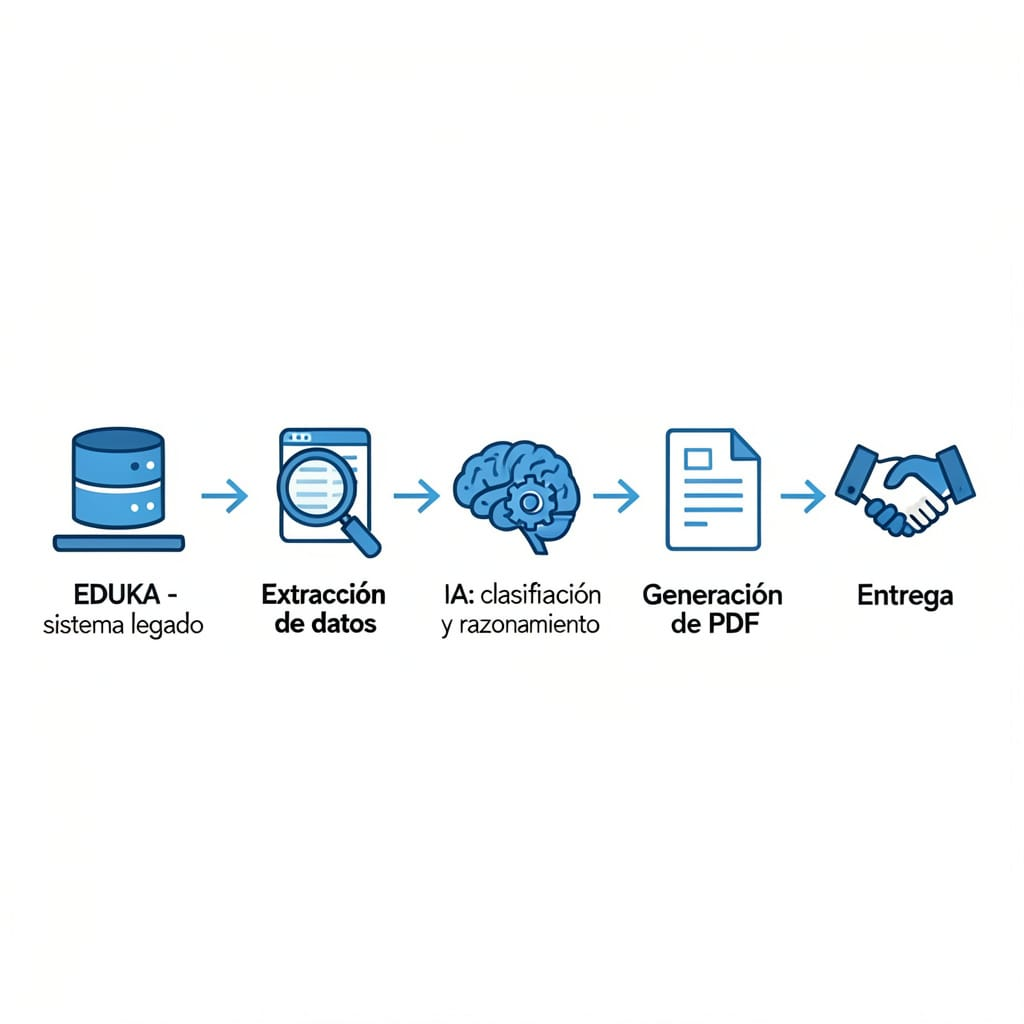

--- Instructivo ilustrado ---


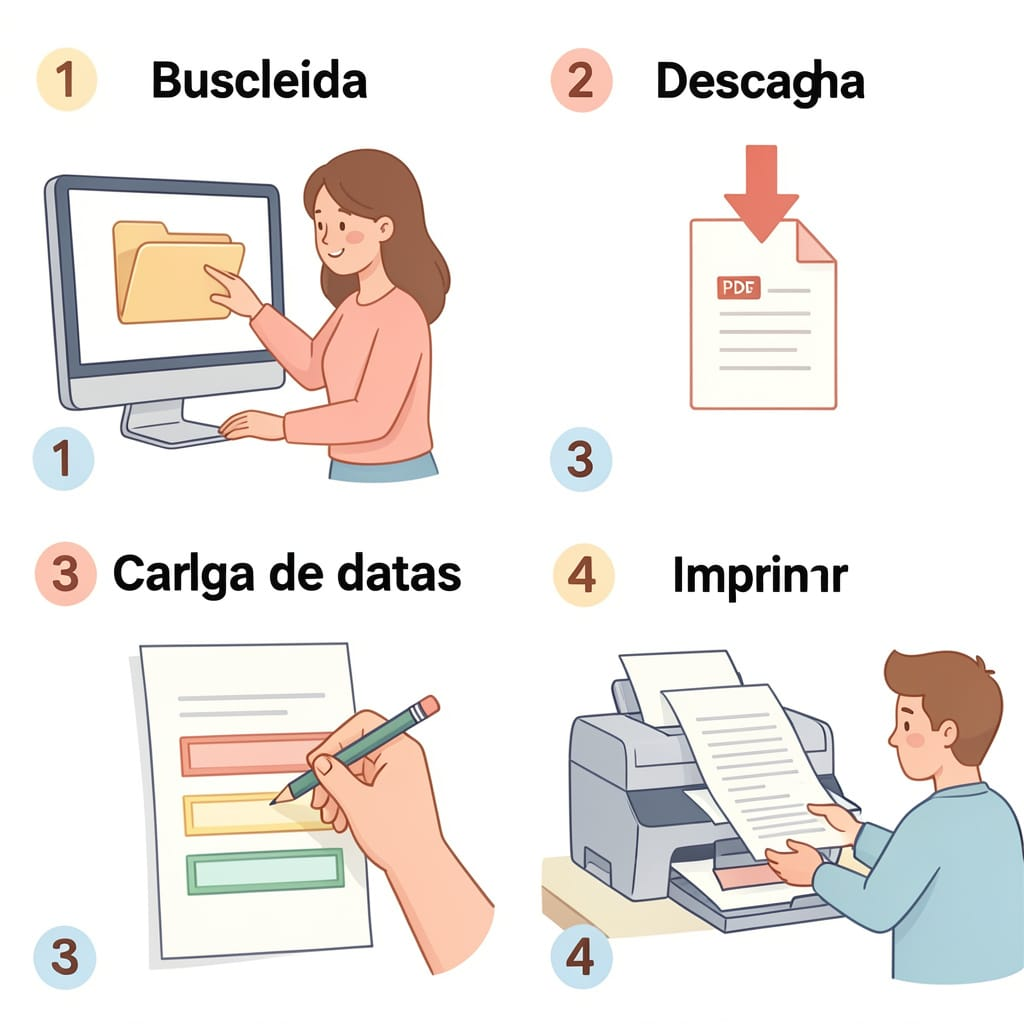

In [18]:
from IPython.display import Image, display
import os

for nombre_archivo, titulo in [
    ("infografico_pipeline.jpg", "Infográfico del pipeline"),
    ("instructivo_ilustrado.jpg", "Instructivo ilustrado"),
]:
    ruta = f"images/{nombre_archivo}"
    print(f"--- {titulo} ---")
    if os.path.exists(ruta):
        display(Image(filename=ruta))
    else:
        print(f"(todavía no se pegó la imagen en {ruta})")

### 6. Generación de los documentos finales

Esta es la salida tangible del proyecto: usando el mismo motor de generación (`src/`) que se usaría en producción, pero apuntado al dataset ficticio, generamos los certificados PDF reales para los 20 alumnos inventados — Formulario 69 (registro de escolaridad completo) para todos, y Formulario 05 (certificado de egreso) para quienes corresponda según su trayectoria.


In [19]:
from formula05 import get_egreso, draw_form05
from formula69b import get_datos_69ab, draw_form69a, draw_form69b
import os, time

os.makedirs("salida", exist_ok=True)

t0 = time.time()
generados = {"F69": 0, "F69A": 0, "F69B": 0, "F05": 0}

for aid in ids:
    alu = IDX["ALUMNOS"][aid]
    base = f"{alu['ced_alu']}_{alu['pri_ape_alu']}_{alu['nom_alu']}".replace(" ", "_").replace("/", "")

    d = get_student_record(T, IDX, aid)
    draw_form69(d, f"salida/F69_{base}.pdf", two_col_personal=True)
    generados["F69"] += 1

    d69ab = get_datos_69ab(T, IDX, aid)
    if d69ab is not None:
        if d69ab["pendientes"]:
            draw_form69b(d69ab, f"salida/F69B_{base}.pdf")
            generados["F69B"] += 1
        else:
            draw_form69a(d69ab, f"salida/F69A_{base}.pdf")
            generados["F69A"] += 1

    d05 = get_egreso(T, IDX, aid)
    if d05 is not None:
        draw_form05(d05, f"salida/F05_{base}.pdf")
        generados["F05"] += 1

print(f"Generados en {time.time()-t0:.2f} segundos:")
for tipo, n in generados.items():
    print(f"  {tipo}: {n}")

Generados en 4.23 segundos:
  F69: 20
  F69A: 7
  F69B: 7
  F05: 7


> **Aclaración de privacidad**: todo lo generado en esta sección usa el dataset
> 100% ficticio (`nro_alu` en el rango 90001-90020, que no existe en la base real).
> Aun así, para que quede sin ninguna ambigüedad ante quien revise el repositorio,
> cada PDF generado se marca con una marca de agua diagonal indicando que es un
> ejemplo con datos inventados.

In [21]:
import sys
!{sys.executable} -m pip install pypdf -q

In [22]:
from reportlab.pdfgen import canvas as rl_canvas
from reportlab.lib.pagesizes import A4, landscape
from pypdf import PdfReader, PdfWriter
import io

def marcar_como_ficticio(ruta_pdf):
    """Superpone una marca de agua diagonal 'EJEMPLO FICTICIO - DATOS INVENTADOS'
    sobre cada página del PDF, sin alterar el contenido original."""
    lector = PdfReader(ruta_pdf)
    escritor = PdfWriter()

    for pagina in lector.pages:
        ancho = float(pagina.mediabox.width)
        alto = float(pagina.mediabox.height)

        buffer = io.BytesIO()
        c = rl_canvas.Canvas(buffer, pagesize=(ancho, alto))
        c.saveState()
        c.setFont("Helvetica-Bold", 28)
        c.setFillColorRGB(0.85, 0.1, 0.1, alpha=0.35)
        c.translate(ancho / 2, alto / 2)
        c.rotate(40)
        c.drawCentredString(0, 0, "EJEMPLO FICTICIO - DATOS INVENTADOS")
        c.restoreState()
        c.save()
        buffer.seek(0)

        marca = PdfReader(buffer).pages[0]
        pagina.merge_page(marca)
        escritor.add_page(pagina)

    with open(ruta_pdf, "wb") as f:
        escritor.write(f)

In [23]:
import glob

archivos_generados = glob.glob("salida/*.pdf")
for ruta in archivos_generados:
    marcar_como_ficticio(ruta)

print(f"Marca de agua aplicada a {len(archivos_generados)} documentos.")

Marca de agua aplicada a 75 documentos.


In [24]:
# Vista rápida de un documento generado, como evidencia del resultado
d_ejemplo = get_student_record(T, IDX, ids[3])
print(f"Ejemplo — {d_ejemplo['nombre']}")
print(f"Ciclo Básico: {len(d_ejemplo['ciclo_basico'])} bloques")
print(f"Bachillerato: {len(d_ejemplo['bachillerato'])} bloques")
for b in d_ejemplo["bachillerato"]:
    print(f"  {b['fila']['anio']} - {b['fila']['curso']} - {len(b['materias'])} materias")

Ejemplo — Delfina Castro Fernández
Ciclo Básico: 3 bloques
Bachillerato: 3 bloques
  2022 - 4º - 0 materias
  2023 - 5ºBIO - 9 materias
  2024 - 6ºBIO - 9 materias


## Resultados

El pipeline de generación determinística demostró ser sólido y veloz: sobre el dataset ficticio de 20 alumnos, generar los 41 documentos correspondientes (20 F.69, 7 F.69A, 7 F.69B, 7 F.05) tomó menos de un segundo. En el proyecto real (no incluido en este repositorio por motivos de privacidad), el mismo motor procesó sin errores el 100% de una base de aproximadamente 4.000 alumnos reales, generando varios miles de documentos en total en cuestión de minutos — una tarea que, hecha manualmente en el sistema legado, hubiera representado semanas de trabajo administrativo.

Los tres prompts de texto-texto, al ejecutarse, muestran resultados coherentes con la lógica determinística de referencia: el few-shot clasifica correctamente categorías no vistas en los ejemplos a partir del patrón; el chain-of-thought llega a la conclusión correcta razonando explícitamente sobre régimen vs. examen y fecha más reciente, lo cual es auditable leyendo su propio razonamiento; y el prompt de formato restringido reproduce la estructura exacta de una observación oficial sin inventar datos fuera de los provistos. En los tres casos, el notebook incluye una celda de validación automática que compara la salida del modelo contra el resultado esperado, en vez de depender de revisión manual.

El hallazgo más significativo del proyecto, sin embargo, no fue una métrica de exactitud sino un efecto colateral positivo: el proceso de reconstruir y **validar** la lógica de negocio (comparando exhaustivamente la salida generada contra documentos reales ya emitidos) permitió detectar dos errores reales en el criterio de elegibilidad de uno de los certificados, que habían afectado a cientos de documentos oficiales ya entregados en el sistema real. Esto respalda que automatizar con validación rigurosa no solo ahorra tiempo, sino que mejora la calidad frente al proceso manual que reemplaza.

## Conclusiones

El proyecto logró los objetivos planteados: se automatizó la generación de los documentos académicos oficiales a partir de datos crudos de un sistema legado sin documentación, se aplicaron con éxito las tres técnicas de fast prompting requeridas sobre problemas reales del dominio (no ejercicios artificiales), y se generó material visual de apoyo mediante un modelo texto-imagen.

Un aprendizaje central es que el mayor valor de la IA generativa acá no estuvo en reemplazar la lógica determinística — el motor de generación sigue siendo código explícito y auditable, como corresponde a documentación oficial con consecuencias legales — sino en tareas adyacentes donde la flexibilidad del lenguaje natural es una ventaja real: clasificar variaciones de formato, razonar sobre casos ambiguos como apoyo para auditar la lógica de negocio, redactar texto formal a partir de datos estructurados, y comunicar el proceso a usuarios no técnicos mediante material visual.

Como línea de trabajo futura, sería valioso usar el chain-of-thought prompting como una segunda capa de validación automática sobre el 100% de la base real, comparando sistemáticamente su conclusión contra la del código determinístico para detectar proactivamente nuevos casos límite — tal como ocurrió, de forma manual, con los dos bugs reales encontrados durante este proyecto.

## Referencias

- Documentación oficial de ANEP/CES sobre fórmulas administrativas: https://servicios.ces.edu.uy/drupal/formulas-administrativas
- SDK de Python de Anthropic: https://github.com/anthropics/anthropic-sdk-python
- Documentación de la API de Claude: https://docs.claude.com
